<div style=" border-bottom: 8px solid #e3f56c; overflow: hidden; border-radius: 10px; height: 95%; width: 100%; display: flex;">
  <div style="height: 100%; width: 100%; background-color: #3800BB; float: left; text-align: center; display: flex; justify-content: left; align-items: center; font-size: 40px; ">
    <b><span style="color: #FFFFFF; padding: 20px 20px;">Santander Customer Satisfaction: LightGBM with Optuna (phik selected features only)</span></b>
  </div>
</div>

<div class="alert" style="background-color: #FFFFFF; border-left: 8px solid #B12111; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **This notebook focuses on developing the initial baseline model for the [Santander Customer Satisfaction competition](https://www.kaggle.com/c/santander-customer-satisfaction/overview).**

FULL PIPELINE FOR BINARY CLASSIFICATION (IMBALANCED DATA)  
**Model**: Decision Tree  
**Imbalance**: ~96% of class 0 and 4% of class 1  

**The main steps include:**

<div class="alert alert-danger">

**Workflow Overview**
</div>


================================================================



- Demonstrate a complete, professional workflow + implementation of decision tree.
- Include preprocessing, handling of imbalance, model tuning, and diagnostics.
- Keep modular structure so each block can be run separately.

1. **Import Libraries and Setup**: Load essential Python libraries for data manipulation, preprocessing, model training, and evaluation.  
2. **Load Data**: Import datasets into memory for analysis and modeling.  
3. **Split into Train/Test Sets**: Divide the data into training and test subsets, typically using an 80/20 ratio for unbiased evaluation.  
4. **Define Preprocessing for Numeric and Categorical Features**: Specify transformations to handle missing values, scale numeric features, and encode categorical variables.  
5. **Define the Model (Random Forest)**: Initialize a Random Forest classifier - a simple, interpretable baseline model for tabular data.  
6. **Build Full Pipeline with Preprocessing + Model**: Combine preprocessing steps and the model into a single pipeline for clean and reproducible workflows.  
7. **Define Hyperparameter Grid for Tuning**: Set up a parameter grid (e.g., `n_estimators`, `criterion`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `bootstrap`, `class_weight`) to optimize model performance.  
8. **Train the Model**: Fit the pipeline on the training data, optionally using cross-validation for robust performance estimation.  
9.  **Save Best Model to Disk**: Persist the trained model for later inference or deployment.  
10. **Evaluate on Test (Validation) Data**: Assess model performance using metrics like ROC AUC, precision, recall, and accuracy.  
11. **Visual Diagnostics (Optional)**: Generate standard classification plots to interpret and validate model behavior:  
    - **ROC Curve**: Examine true vs. false positive rates.  
    - **Precision–Recall Curve**: Evaluate trade-offs between precision and recall.  
    - **Confusion Matrix**: Visualize correct vs. incorrect predictions.  
    - **Learning Curve**: Understand performance changes with varying training sizes.  
    - **Validation Curve**: Analyze sensitivity to a key hyperparameter (e.g., `max_depth`).  
    - **Feature Importances**: Identify which features most influence predictions.   
    - **Calibration (Reliability) Plot**: Check how well predicted probabilities align with observed outcomes.  
12. **Make Predictions on Holdout (Test Data)**: Generate final predicted labels and probabilities for unseen samples to estimate real-world performance.



<div class="alert alert-danger">

**Outputs**
</div>
================================================================

- Baseline Decision Tree Model (../src/models/03_05_lgbm_with_OPTUNA.joblib)
- Predicted test file (../src/subs/03_05_lgbm_with_OPTUNA.csv)

</div>

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Import Libraries and Setup**
Needed for data handling, model building, preprocessing, and evaluation.

</div>

In [1]:
import sys
import os
# Add the parent directory to the Python path
sys.path.append(os.path.abspath('..'))


from src.data.data_utils import (
    setup_logging,
    load_data,
    intersect_features,
)
from src.data.data_utils import FeaturesUtils
setup_logging("03_05_lgbm_with_OPTUNA.log")


import pickle
from classes import Paths
import pandas as pd
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)
import numpy as np
import warnings
warnings.filterwarnings("ignore")


import scipy
import scipy.stats
from matplotlib import pyplot as plt
import math
import seaborn as sns


# from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, GridSearchCV, learning_curve, validation_curve, StratifiedKFold, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, accuracy_score, roc_auc_score
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
import optuna

# For imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Load Data**

</div>

In [2]:
paths = Paths()
# Load the data
train_data = load_data(paths.get_interim_data_path("train_cleaned.csv"))
test_data = load_data(paths.get_interim_data_path("test_cleaned.csv"))
train_data.head()
# Target variable
train_data["TARGET"] = train_data["TARGET"].astype(int)

print("Target distribution (imbalance check):")
print(train_data["TARGET"].value_counts(normalize=True).round(2))

print(train_data.shape)

Target distribution (imbalance check):
TARGET
0   0.96
1   0.04
Name: proportion, dtype: float64
(76020, 185)


<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Remove unnecessary data**

</div>

In [3]:
with open("../src/reports/cols_phik_5p_Series.pkl", "rb") as f:
    loaded_cols_phik_5p_Series = pickle.load(f)
print(len(loaded_cols_phik_5p_Series)-1)
display(loaded_cols_phik_5p_Series)

34


TARGET                          1.00
ind_var30                       0.23
num_meses_var5_ult3             0.23
saldo_var42                     0.20
saldo_medio_var5_ult3           0.19
saldo_medio_var5_hace3          0.17
num_var35                       0.16
var15                           0.15
saldo_var30                     0.15
num_var30                       0.15
saldo_medio_var5_hace2          0.14
num_var42                       0.13
saldo_medio_var5_ult1           0.13
saldo_var5                      0.13
num_var5                        0.11
var36                           0.09
num_meses_var39_vig_ult3        0.07
ind_var13_0                     0.06
var38                           0.06
ind_var12_0                     0.06
saldo_var13                     0.06
num_var12_0                     0.06
ind_var5_0                      0.05
ind_var12                       0.05
saldo_medio_var12_hace2         0.05
ind_var24                       0.05
num_var30_0                     0.05
i

In [4]:
# df_train = train_data[loaded_cols_phik_5p_Series.index.to_list()]
df_train = train_data.copy()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Split into train/test sets**
Standard practice — keep 20% for final evaluation.
</div>

In [5]:
y = df_train['TARGET']
df_train, df_test = intersect_features(
    train_dataframe=train_data
    , test_dataframe=test_data
)

X = df_train.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

Finding common features between train and test datasets.


<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Define preprocessing for numeric and categorical features**
To handle missing values, scale numeric features, and encode categorical variables.

</div>

In [6]:
# load categorical and numerical feature lists
with open("../src/features/interval_columns_list.pkl", "rb") as f:
    loaded_interval_cols = pickle.load(f)
with open("../src/features/categorical_columns_list.pkl", "rb") as f:
    loaded_categorical_cols = pickle.load(f)

# ===============================================
# Identify feature types
# ===============================================
numeric_cols = [c for c in loaded_interval_cols if c in X_train.columns]
categorical_cols = [c for c in loaded_categorical_cols if c in X_train.columns]

# Numeric: median imputation + standard scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical: most frequent imputation + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Define the model (LightGBM)**
Easy to interpret baseline for tabular data.

</div>

In [8]:
from lightgbm import LGBMClassifier
import lightgbm as lgb

import logging

# Comprehensive warning suppression
lgb.register_logger(logging.getLogger("lightgbm"))
logging.getLogger("lightgbm").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")
warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ===============================================
# Define model and pipeline
# ===============================================
lgbm = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)

pipe = Pipeline(steps=[
    ("preproc", preprocessor),
    ("clf", lgbm)
])

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Build full pipeline with preprocessing + model**

</div>

In [9]:
# # Option A: Simple pipeline (with class_weight balancing)
pipe = Pipeline(steps=[
    ("preproc", preprocessor),
    ("clf", lgbm)
])

# Option B: Pipeline with SMOTE oversampling
# In addition to class weights, SMOTE synthetically generates minority samples to balance the training set.

# pipe = ImbPipeline(steps=[
# ("preproc", preprocessor),
# ("smote", SMOTE(random_state=42)),
# ("clf", dt)
# ])

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Define hyperparameter grid for tuning**
Decision Trees are sensitive to depth, splits, and leaf size.

</div>

pos_weight = (y == 0).sum() / (y == 1).sum()

# ===============================================
# Objective function
# ===============================================
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500, step=300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 50, step=5),
        "max_depth": trial.suggest_categorical("max_depth", [4, 6, 8, 10]),
        "min_child_samples": trial.suggest_int("min_child_samples", 50, 300, step=50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0, step=0.1),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0, step=0.1),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0, step=0.1),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0, step=0.1),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 10.0, log=True),
        "scale_pos_weight": pos_weight,
        "objective": "binary",
        "boosting_type": "gbdt",
        "n_jobs": -1,
    }

    pipe.set_params(**{f"clf__{k}": v for k, v in params.items()})

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    mean_score = np.mean(scores)

    if (trial.number + 1) % 10 == 0:
        best_val = trial.study.best_value if trial.study.best_value else mean_score
        print(f"[Trial {trial.number + 1:03}] ROC-AUC: {mean_score:.5f} | Best: {best_val:.5f}")

    return mean_score

# ===============================================
# Create or load study
# ===============================================
study = optuna.create_study(
    direction="maximize",
    study_name="LGBM_AUC",
    storage="sqlite:///03_05_lgbm_with_OPTUNA.db",
    load_if_exists=True
)

# ===============================================
# Optimize
# ===============================================
study.optimize(objective, n_trials=30, n_jobs=1, show_progress_bar=False)

# ===============================================
# Results
# ===============================================
print("\n=== OPTIMIZATION COMPLETE ===")
print(f"Best CV ROC AUC: {study.best_value:.5f}")
print("Best params:", study.best_params)

In [10]:
# ===============================================
# Silence optuna + warnings
# ===============================================
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

pos_weight = (y == 0).sum() / (y == 1).sum()
# ===============================================
# Objective function
# ===============================================
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500, step=300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 50, step=5),
        "max_depth": trial.suggest_categorical("max_depth", [4, 6, 8, 10]),
        "min_child_samples": trial.suggest_int("min_child_samples", 50, 300, step=50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0, step=0.1),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0, step=0.1),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0, step=0.1),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0, step=0.1),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 10.0, log=True),
        "scale_pos_weight": pos_weight,
        "objective": "binary",
        "boosting_type": "gbdt",
        "n_jobs": -1,
        "verbose": -1
    }


    pipe.set_params(**{f"clf__{k}": v for k, v in params.items()})

    # Stratified 5-fold CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Compute mean ROC-AUC
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    mean_score = np.mean(scores)

    # Controlled verbosity — print every 10th trial
    if (trial.number + 1) % 10 == 0:
        best_so_far = trial.study.best_value if trial.study.best_value is not None else mean_score
        print(f"[Trial {trial.number + 1:03}] Mean ROC-AUC: {mean_score:.5f} | Best so far: {best_so_far:.5f}")

    return mean_score

# ===============================================
# Create or load Optuna study
# ===============================================
study = optuna.create_study(
    direction="maximize",
    study_name="LGBM_AUC",
    storage="sqlite:///03_05_lgbm_with_OPTUNA.db",
    load_if_exists=True
)

# ===============================================
# Run optimization
# ===============================================
study.optimize(objective, n_trials=30, n_jobs=1, show_progress_bar=True)

# ===============================================
# Final results
# ===============================================
print("\n=== OPTIMIZATION COMPLETE ===")
print(f"Best CV ROC AUC: {study.best_value:.5f}")
print("Best params:", study.best_params)

# ===============================================
# Visualizations
# ===============================================
display(optuna.visualization.plot_param_importances(study))
display(optuna.visualization.plot_optimization_history(study))

  0%|          | 0/30 [00:00<?, ?it/s]

[Trial 040] Mean ROC-AUC: 0.83401 | Best so far: 0.83668
[Trial 050] Mean ROC-AUC: 0.82137 | Best so far: 0.83668
[Trial 060] Mean ROC-AUC: 0.83382 | Best so far: 0.83668

=== OPTIMIZATION COMPLETE ===
Best CV ROC AUC: 0.83668
Best params: {'n_estimators': 300, 'learning_rate': 0.02098844552913404, 'num_leaves': 15, 'max_depth': 4, 'min_child_samples': 300, 'subsample': 0.8, 'colsample_bytree': 0.7, 'feature_fraction': 0.6, 'bagging_fraction': 0.9, 'reg_alpha': 1.2112548276452944e-05, 'reg_lambda': 0.009628649992854165}


<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Train the model**

</div>

In [11]:
# ===============================================
# Retrain best model on full training data
# ===============================================
lgbm_best_params = {f"clf__{k}": v for k, v in study.best_params.items()}
pipe.set_params(**lgbm_best_params)
lgbm_best_model = pipe.fit(X_train, y_train)

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Save best model to disk**
Each section below includes a standard visualization for classification model diagnostics.

</div>

In [12]:
import joblib

joblib.dump(lgbm_best_model, paths.get_model_path("03_05_lgbm_with_OPTUNA.joblib"))

['../src/models/03_05_lgbm_with_OPTUNA.joblib']

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Evaluate on test (validation) data**

</div>

In [14]:
y_pred = lgbm_best_model.predict(X_test)
y_proba = lgbm_best_model.predict_proba(X_test)[:, 1]

print("\nROC AUC:", roc_auc_score(y_test, y_proba))
print("Average Precision (PR AUC):", average_precision_score(y_test, y_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))


ROC AUC: 0.850553228270282
Average Precision (PR AUC): 0.18829447609222502
Accuracy: 0.7713759536963957

Classification Report:
               precision    recall  f1-score   support

           0      0.988     0.771     0.866     14602
           1      0.123     0.779     0.213       602

    accuracy                          0.771     15204
   macro avg      0.556     0.775     0.539     15204
weighted avg      0.954     0.771     0.840     15204



<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Visual diagnostics**
Each section below includes a standard visualization for classification model diagnostics.

</div>

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**ROC Curve (true vs false positive rates)**
</div>

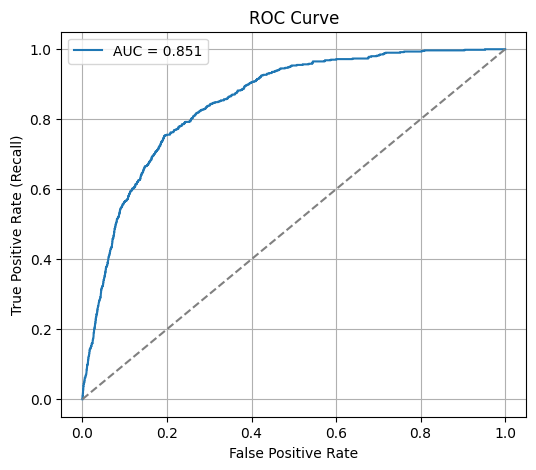

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr,tpr):.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Precision–Recall Curve**
</div>

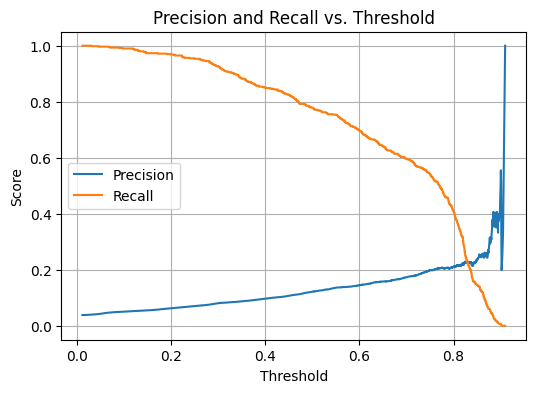

In [17]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 4))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs. Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
from sklearn.metrics import precision_recall_curve, f1_score

y_proba = lgbm_best_model.predict_proba(X_test)[:, 1]
prec, rec, thres = precision_recall_curve(y_test, y_proba)
f1 = 2 * prec * rec / (prec + rec)
best_idx = f1.argmax()
best_threshold = thres[best_idx]
print(f"Best threshold: {best_threshold:.3f} | F1: {f1[best_idx]:.3f}")

y_pred_adj = (y_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_adj))

Best threshold: 0.766 | F1: 0.295
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     14602
           1       0.21      0.51      0.29       602

    accuracy                           0.90     15204
   macro avg       0.59      0.72      0.62     15204
weighted avg       0.95      0.90      0.92     15204



In [19]:
best_threshold

0.7663208188350369

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Confusion Matrix**
</div>

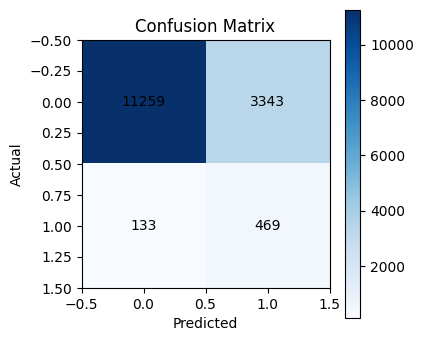

In [20]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
for (i,j), val in np.ndenumerate(cm):
    plt.text(j, i, int(val), ha="center", va="center")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Learning Curve — how performance changes with more data**
</div>

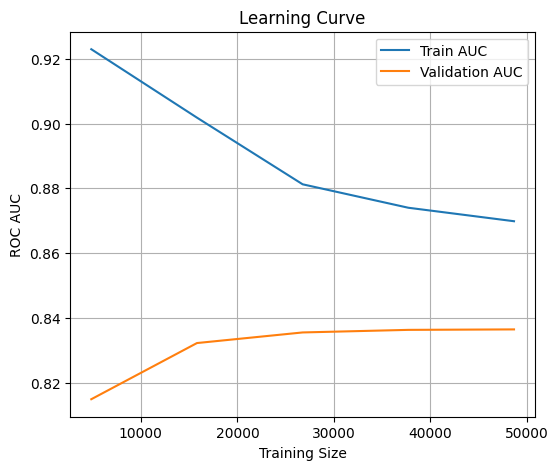

In [21]:
train_sizes, train_scores, val_scores = learning_curve(
    lgbm_best_model, X_train, y_train,
    cv=5, scoring="roc_auc", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)
plt.figure(figsize=(6,5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Train AUC")
plt.plot(train_sizes, np.mean(val_scores, axis=1), label="Validation AUC")
plt.xlabel("Training Size")
plt.ylabel("ROC AUC")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Validation Curve - sensitivity to a single hyperparameter (max_depth)**
</div>

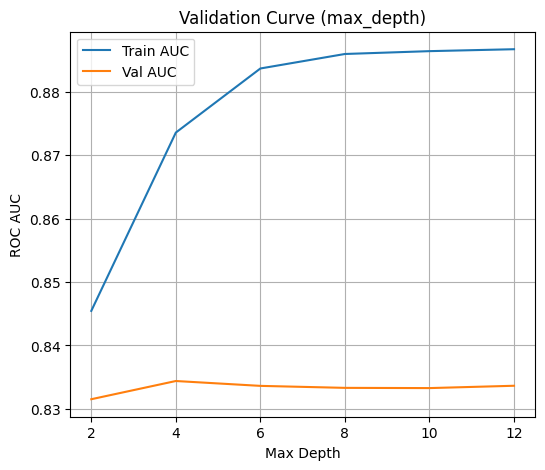

In [22]:
param_range = [2,4,6,8,10,12]
train_scores, test_scores = validation_curve(
    pipe, X_train, y_train,
    param_name="clf__max_depth",
    param_range=param_range,
    cv=3,
    scoring="roc_auc"
)
plt.figure(figsize=(6,5))
plt.plot(param_range, np.mean(train_scores, axis=1), label="Train AUC")
plt.plot(param_range, np.mean(test_scores, axis=1), label="Val AUC")
plt.xlabel("Max Depth")
plt.ylabel("ROC AUC")
plt.title("Validation Curve (max_depth)")
plt.legend()
plt.grid(True)
plt.show()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Feature Importances - interpretability**
</div>

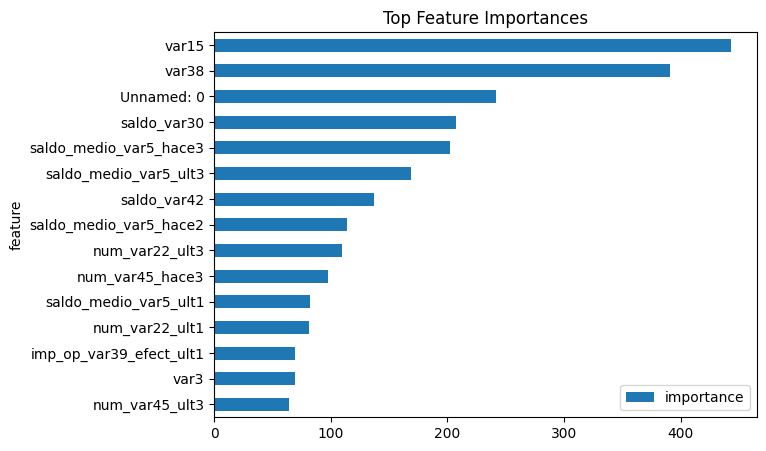

In [23]:
preproc = lgbm_best_model.named_steps["preproc"]
num_names = numeric_cols
ohe = preproc.named_transformers_["cat"].named_steps["onehot"]
cat_names = list(ohe.get_feature_names_out(categorical_cols))
feature_names_all = num_names + cat_names

importances = lgbm_best_model.named_steps["clf"].feature_importances_
feat_imp = pd.DataFrame({"feature": feature_names_all, "importance": importances})
feat_imp.sort_values("importance", ascending=False, inplace=True)
feat_imp.head(15).plot.barh(x="feature", y="importance", figsize=(7,5), title="Top Feature Importances")
plt.gca().invert_yaxis()
plt.show()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Calibration (Reliability) Plot**
</div>

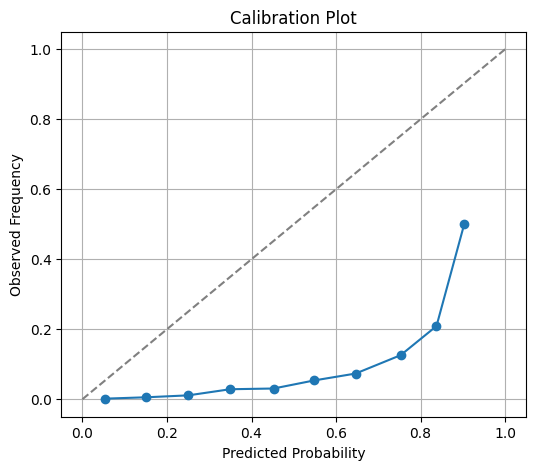

In [24]:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, "o-")
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Plot")
plt.grid(True)
plt.show()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Make Predictions on Holdout (Test Data)**
Generate predicted labels and probabilities for unseen samples.

</div>

In [25]:
# change threshold
# add ID column back to df_test
test_ids = pd.read_csv(paths.get_interim_data_path("test_ids.csv"))
df_test["ID"] = test_ids["ID"]

# Ensure test dataset contains same columns as train
assert all(col in df_test.columns for col in X_train.columns), \
    "df_test must contain same feature columns as training data."

# --- Predict class probabilities and labels
y_test_pred_proba = lgbm_best_model.predict_proba(df_test)[:, 1]   # probability of class 1
y_test_pred_label = lgbm_best_model.predict(df_test)               # 0/1 hard predictions

# --- Attach predictions to original dataframe
df_test_pred = df_test.copy()
df_test_pred["pred_proba"] = y_test_pred_proba
df_test_pred["pred_label"] = y_test_pred_label

# --- Inspect results
print(df_test_pred[["pred_proba", "pred_label"]].head())

# --- Save to file for submission or analysis
# baseline submission file
df_test_pred_labels = df_test_pred[["ID", "pred_label"]]
# change threshold
threshold = 0.5
df_test_pred["pred_label_thresholded"] = (df_test_pred["pred_proba"] >= threshold).astype(int)
df_test_pred_labels = df_test_pred[["ID", "pred_label_thresholded"]]
# rename columns for submission
df_test_pred_labels.columns = ["ID", "TARGET"]
display(df_test_pred_labels)

df_test_pred_labels.to_csv(
    paths.get_subs_path("03_05_lgbm_with_OPTUNA.csv")
    , index=False
)


   pred_proba  pred_label
0        0.56           1
1        0.60           1
2        0.03           0
3        0.16           0
4        0.04           0


,ID,TARGET
0,2,1
1,5,1
2,6,0
3,7,0
4,9,0
...,...,...
75813,151831,1
75814,151832,0
75815,151833,0
75816,151834,1
